# 公式 o4 — Attractors（カオス力学系）

> **出典（E-Cell4 公式）**: Examples / example01 *Attractors* — https://ecell4.e-cell.org/examples/example01.html
>
> E-Cell4 は反応シミュレータだが、`~x > x | 速度式` の rate-law 記法で**任意の連立 ODE** を書けるので、
> 化学反応でない**カオス力学系**も解ける。公式例題の 5 系をそのまま移植（描画のみ matplotlib）。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

def solve(rules_fn, y0, t, ndiv, species):
    rules_fn(); m = get_model()
    return run_simulation(t, ndiv=ndiv, y0=y0, model=m, species_list=species).as_array()

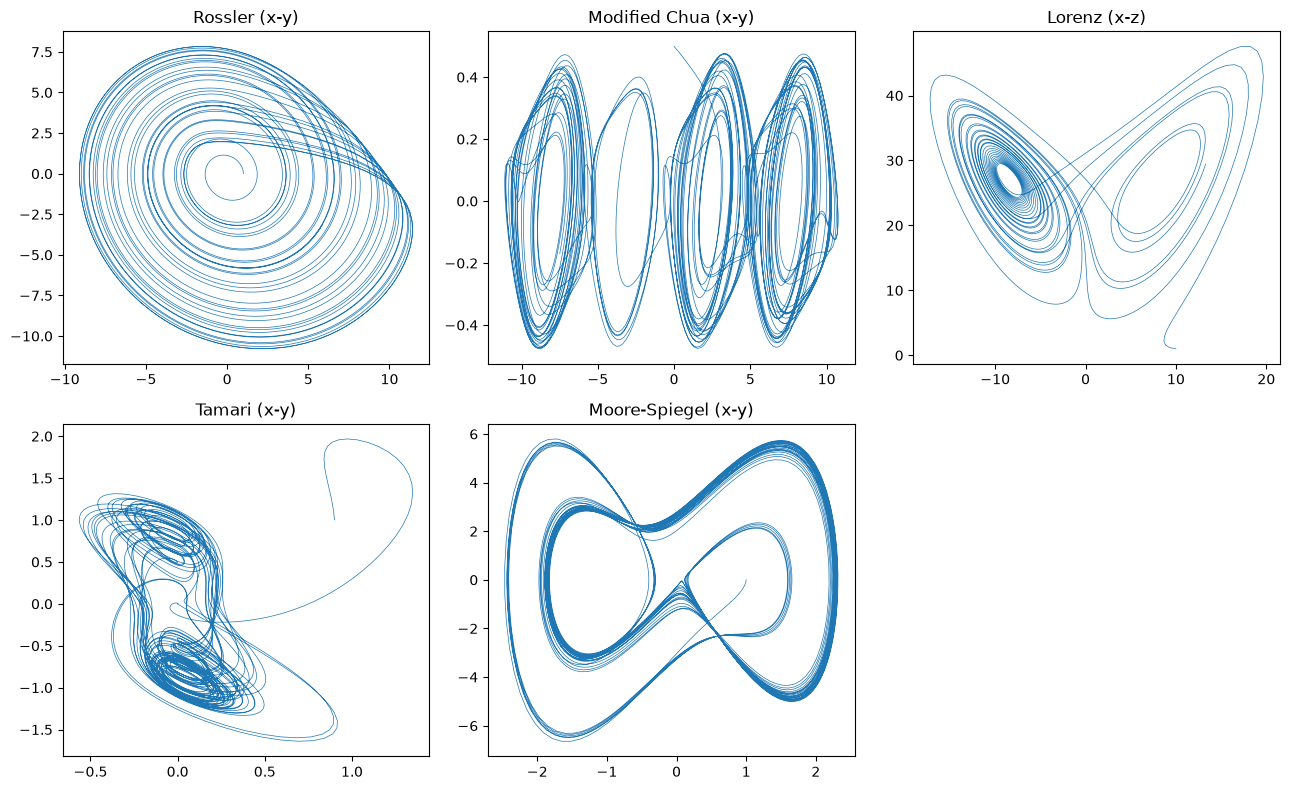

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8)); ax = axes.ravel()

# 1. Rossler
def rossler():
    a,b,c=0.2,0.2,5.7
    with reaction_rules():
        ~x > x | (-y - z); ~y > y | (x + a*y); ~z > z | (b + z*(x - c))
d=solve(rossler, {'x':1.0}, 200, 4000, ['x','y','z']); ax[0].plot(d[:,1], d[:,2], lw=.5); ax[0].set_title('Rossler (x-y)')

# 2. Modified Chua
def chua():
    alpha,beta=10.82,14.286; a,b,d0=1.3,0.1,0.2
    with reaction_rules():
        h = -b*sin(pi*x/(2*a)+d0)
        ~x > x | (alpha*(y-h)); ~y > y | (x-y+z); ~z > z | (-beta*y)
d=solve(chua, {'x':0,'y':0.49899,'z':0.2}, 250, 5000, ['x','y','z']); ax[1].plot(d[:,1], d[:,2], lw=.5); ax[1].set_title('Modified Chua (x-y)')

# 3. Lorenz
def lorenz():
    p,r,b=10,28,8.0/3
    with reaction_rules():
        ~x > x | (-p*x+p*y); ~y > y | (-x*z+r*x-y); ~z > z | (x*y-b*z)
d=solve(lorenz, {'x':10,'y':1,'z':1}, 25, 2500, ['x','y','z']); ax[2].plot(d[:,1], d[:,3], lw=.5); ax[2].set_title('Lorenz (x-z)')

# 4. Tamari
def tamari():
    a,b,c,d1,e,f,g,u,i=1.013,-0.021,0.019,0.96,0,0.01,1,0.05,0.05
    with reaction_rules():
        ~x > x | ((x-a*y)*cos(z)-b*y*sin(z)); ~y > y | ((x+c*y)*sin(z)+d1*y*cos(z))
        ~z > z | (e+f*z+g*a*atan((1-u)/(1-i)*x*y))
d=solve(tamari, {'x':0.9,'y':1,'z':1}, 800, 8000, ['x','y','z']); ax[3].plot(d[:,1], d[:,2], lw=.5); ax[3].set_title('Tamari (x-y)')

# 5. Moore-Spiegel
def moore():
    T,R=6,20
    with reaction_rules():
        ~x > x | y; ~y > y | z; ~z > z | (-z-(T-R+R*x*x)*y-T*x)
d=solve(moore, {'x':1,'y':0,'z':0}, 100, 5001, ['x','y','z']); ax[4].plot(d[:,1], d[:,2], lw=.5); ax[4].set_title('Moore-Spiegel (x-y)')

ax[5].axis('off')
plt.tight_layout(); plt.show()

## 読み取り

いずれも**カオス的アトラクタ**——決定論的なのに初期値鋭敏で、位相空間に非周期の複雑な軌道を描く（Lorenz の蝶形が有名）。

**要点（公式が教えたい機能）**: `~x > x | <任意の式>` の rate-law 記法で、E-Cell4 を**汎用 ODE ソルバ**として使える。
反応系に限らず微分方程式なら何でも書ける（`sin/cos/exp/atan/pi` 等も式中で使える）。